In [2]:
import pandas as pd

df = pd.read_csv("data/HDFS_2k.log_structured.csv")
df.head()


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


In [4]:
WINDOW_SIZE = 5

sequences = []
for i in range(len(df) - WINDOW_SIZE):
    seq = df.iloc[i:i+WINDOW_SIZE]["EventId"].tolist()
    sequences.append(seq)

seq_df = pd.DataFrame({"sequence": sequences})


In [14]:
seq_df.head()

,sequence,seq_str,anomaly
0,"[E10, E10, E6, E10, E10]",E10 E10 E6 E10 E10,Normal
1,"[E10, E6, E10, E10, E6]",E10 E6 E10 E10 E6,Normal
2,"[E6, E10, E10, E6, E6]",E6 E10 E10 E6 E6,Normal
3,"[E10, E10, E6, E6, E6]",E10 E10 E6 E6 E6,Normal
4,"[E10, E6, E6, E6, E10]",E10 E6 E6 E6 E10,Normal


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

seq_df["seq_str"] = seq_df["sequence"].apply(lambda x: " ".join(x))

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(seq_df["seq_str"])

In [6]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
seq_df["anomaly"] = model.fit_predict(X)
seq_df["anomaly"] = seq_df["anomaly"].map({1: "Normal", -1: "Anomalous"})


In [7]:
anomalous_seq = seq_df[seq_df["anomaly"] == "Anomalous"]
anomalous_seq.head()


,sequence,seq_str,anomaly
25,"[E13, E11, E7, E14, E11]",E13 E11 E7 E14 E11,Anomalous
26,"[E11, E7, E14, E11, E13]",E11 E7 E14 E11 E13,Anomalous
27,"[E7, E14, E11, E13, E11]",E7 E14 E11 E13 E11,Anomalous
65,"[E11, E11, E10, E11, E14]",E11 E11 E10 E11 E14,Anomalous
68,"[E11, E14, E13, E10, E9]",E11 E14 E13 E10 E9,Anomalous


In [8]:
from collections import Counter

flat_events = [event for seq in anomalous_seq["sequence"] for event in seq]
Counter(flat_events).most_common(5)


[('E3', 95), ('E14', 72), ('E1', 49), ('E7', 46), ('E11', 44)]

In [9]:
event_map = df.drop_duplicates("EventId")[["EventId", "EventTemplate"]]
event_map[event_map["EventId"].isin(["E10", "E6"])]


,EventId,EventTemplate
0,E10,PacketResponder <*> for block blk_<*> terminating
2,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...


<Axes: title={'center': 'Sequence Anomalies'}, xlabel='anomaly'>

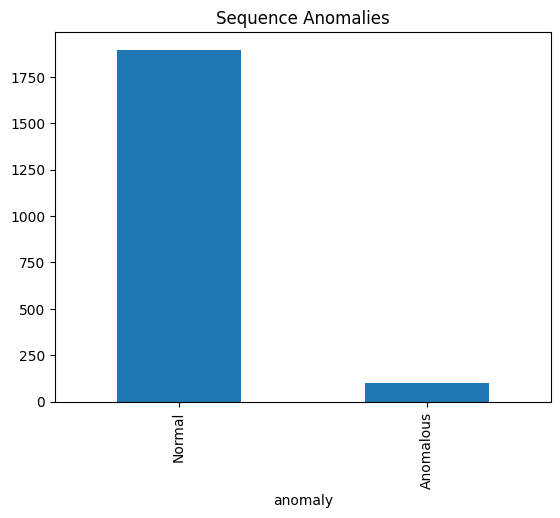

In [ ]:
seq_df["anomaly"].value_counts().plot(kind="bar", title="Sequence Anomalies")